In [3]:
import pandas as pd


In [4]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)

# -----------------------------
# Configuration
# -----------------------------

N = 5000

project_types = [
    "Solar",
    "Wind",
    "Hydro",
    "Thermal",
    "Transmission"
]

states = [
    "Rajasthan",
    "Gujarat",
    "Maharashtra",
    "Tamil Nadu",
    "Karnataka",
    "Uttar Pradesh",
    "Madhya Pradesh",
    "Punjab",
    "Haryana",
    "Andhra Pradesh"
]

regions = {
    "Rajasthan": "North",
    "Gujarat": "West",
    "Maharashtra": "West",
    "Tamil Nadu": "South",
    "Karnataka": "South",
    "Uttar Pradesh": "North",
    "Madhya Pradesh": "Central",
    "Punjab": "North",
    "Haryana": "North",
    "Andhra Pradesh": "South"
}

land_statuses = [
    "Complete",
    "Partial",
    "Pending"
]

complexities = [
    "Low",
    "Medium",
    "High"
]

# -----------------------------
# Helper Functions
# -----------------------------

def generate_project_specs(project_type):

    if project_type == "Solar":
        capacity = np.random.randint(50, 1500)
        budget = capacity * np.random.uniform(1.5, 3.5)
        duration = np.random.randint(12, 48)

    elif project_type == "Wind":
        capacity = np.random.randint(50, 1000)
        budget = capacity * np.random.uniform(1.2, 3.0)
        duration = np.random.randint(12, 36)

    elif project_type == "Hydro":
        capacity = np.random.randint(100, 4000)
        budget = capacity * np.random.uniform(3.0, 8.0)
        duration = np.random.randint(36, 120)

    elif project_type == "Thermal":
        capacity = np.random.randint(500, 5000)
        budget = capacity * np.random.uniform(2.5, 6.5)
        duration = np.random.randint(36, 96)

    else:  # Transmission
        capacity = np.random.randint(100, 3000)
        budget = capacity * np.random.uniform(1.0, 2.5)
        duration = np.random.randint(12, 60)

    return capacity, round(budget, 2), duration


def calculate_overruns(
    budget,
    duration,
    land_status,
    complexity,
    contractor_count
):

    cost_overrun = np.random.uniform(0, 5)
    delay_months = np.random.uniform(0, 2)

    # Land acquisition impact
    if land_status == "Partial":
        cost_overrun += np.random.uniform(5, 15)
        delay_months += np.random.uniform(2, 8)

    elif land_status == "Pending":
        cost_overrun += np.random.uniform(10, 30)
        delay_months += np.random.uniform(6, 18)

    # Complexity impact
    if complexity == "Medium":
        cost_overrun += np.random.uniform(3, 8)
        delay_months += np.random.uniform(1, 4)

    elif complexity == "High":
        cost_overrun += np.random.uniform(5, 20)
        delay_months += np.random.uniform(3, 12)

    # Contractor impact
    if contractor_count > 7:
        cost_overrun += np.random.uniform(2, 10)
        delay_months += np.random.uniform(1, 6)

    actual_cost = budget * (1 + cost_overrun / 100)
    actual_duration = duration + delay_months

    return (
        round(actual_cost, 2),
        round(actual_duration, 1),
        round(cost_overrun, 2),
        round(delay_months, 1)
    )


def assign_risk(cost_overrun, delay):

    if cost_overrun > 25 or delay > 9:
        return "High"

    elif cost_overrun >= 10 or delay >= 3:
        return "Medium"

    else:
        return "Low"


# -----------------------------
# Generate Dataset
# -----------------------------

rows = []

for i in range(N):

    project_type = np.random.choice(project_types)

    state = np.random.choice(states)

    region = regions[state]

    capacity_mw, budget, duration = generate_project_specs(
        project_type
    )

    contractor_count = np.random.randint(1, 11)

    land_status = np.random.choice(
        land_statuses,
        p=[0.50, 0.35, 0.15]
    )

    complexity = np.random.choice(
        complexities,
        p=[0.30, 0.50, 0.20]
    )

    (
        actual_cost,
        actual_duration,
        cost_overrun,
        delay_months
    ) = calculate_overruns(
        budget,
        duration,
        land_status,
        complexity,
        contractor_count
    )

    risk_level = assign_risk(
        cost_overrun,
        delay_months
    )

    rows.append([
        f"P{i+1:05d}",
        project_type,
        state,
        region,
        capacity_mw,
        budget,
        duration,
        contractor_count,
        land_status,
        complexity,
        actual_cost,
        actual_duration,
        cost_overrun,
        delay_months,
        risk_level
    ])

# -----------------------------
# Create DataFrame
# -----------------------------

columns = [
    "project_id",
    "project_type",
    "state",
    "region",
    "capacity_mw",
    "sanctioned_budget_cr",
    "planned_duration_months",
    "contractor_count",
    "land_acquisition_status",
    "project_complexity",
    "actual_cost_cr",
    "actual_duration_months",
    "cost_overrun_pct",
    "delay_months",
    "risk_level"
]

df = pd.DataFrame(rows, columns=columns)

# -----------------------------
# Save Dataset
# -----------------------------

df.to_csv(
    "powercast_dataset.csv",
    index=False
)

print("Dataset Created Successfully")
print(df.shape)

print("\nFirst 5 Rows:")
print(df)

print("\nRisk Distribution:")
print(df["risk_level"].value_counts())


Dataset Created Successfully
(5000, 15)

First 5 Rows:
     project_id  project_type           state   region  capacity_mw  \
0        P00001       Thermal          Punjab    North         4272   
1        P00002       Thermal   Uttar Pradesh    North         2933   
2        P00003       Thermal     Maharashtra     West         2399   
3        P00004          Wind      Tamil Nadu    South          141   
4        P00005          Wind  Andhra Pradesh    South          605   
...         ...           ...             ...      ...          ...   
4995     P04996         Hydro       Rajasthan    North         3878   
4996     P04997  Transmission  Madhya Pradesh  Central          228   
4997     P04998       Thermal  Madhya Pradesh  Central         4443   
4998     P04999  Transmission  Madhya Pradesh  Central         1559   
4999     P05000         Hydro     Maharashtra     West         2283   

      sanctioned_budget_cr  planned_duration_months  contractor_count  \
0                 2

In [5]:
df


,project_id,project_type,state,region,capacity_mw,sanctioned_budget_cr,planned_duration_months,contractor_count,land_acquisition_status,project_complexity,actual_cost_cr,actual_duration_months,cost_overrun_pct,delay_months,risk_level
0,P00001,Thermal,Punjab,North,4272,20878.98,93,3,Complete,Medium,22533.22,94.5,7.92,1.5,Low
1,P00002,Thermal,Uttar Pradesh,North,2933,9465.67,56,1,Complete,Medium,10243.65,58.0,8.22,2.0,Low
2,P00003,Thermal,Maharashtra,West,2399,10932.09,92,3,Pending,Medium,14870.22,105.8,36.02,13.8,High
3,P00004,Wind,Tamil Nadu,South,141,280.91,18,8,Complete,High,329.63,28.9,17.34,10.9,High
4,P00005,Wind,Andhra Pradesh,South,605,1749.11,15,8,Partial,Medium,2275.05,28.2,30.07,13.2,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P04996,Hydro,Rajasthan,North,3878,20110.49,41,10,Complete,High,24518.21,55.1,21.92,14.1,High
4996,P04997,Transmission,Madhya Pradesh,Central,228,343.92,57,1,Complete,High,375.63,65.0,9.22,8.0,Medium
4997,P04998,Thermal,Madhya Pradesh,Central,4443,18230.84,81,1,Complete,Low,18279.98,81.2,0.27,0.2,Low
4998,P04999,Transmission,Madhya Pradesh,Central,1559,1948.56,34,2,Pending,Medium,2339.66,50.2,20.07,16.2,High


In [6]:
df.shape


(5000, 15)

In [7]:
df.drop_duplicates()


,project_id,project_type,state,region,capacity_mw,sanctioned_budget_cr,planned_duration_months,contractor_count,land_acquisition_status,project_complexity,actual_cost_cr,actual_duration_months,cost_overrun_pct,delay_months,risk_level
0,P00001,Thermal,Punjab,North,4272,20878.98,93,3,Complete,Medium,22533.22,94.5,7.92,1.5,Low
1,P00002,Thermal,Uttar Pradesh,North,2933,9465.67,56,1,Complete,Medium,10243.65,58.0,8.22,2.0,Low
2,P00003,Thermal,Maharashtra,West,2399,10932.09,92,3,Pending,Medium,14870.22,105.8,36.02,13.8,High
3,P00004,Wind,Tamil Nadu,South,141,280.91,18,8,Complete,High,329.63,28.9,17.34,10.9,High
4,P00005,Wind,Andhra Pradesh,South,605,1749.11,15,8,Partial,Medium,2275.05,28.2,30.07,13.2,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P04996,Hydro,Rajasthan,North,3878,20110.49,41,10,Complete,High,24518.21,55.1,21.92,14.1,High
4996,P04997,Transmission,Madhya Pradesh,Central,228,343.92,57,1,Complete,High,375.63,65.0,9.22,8.0,Medium
4997,P04998,Thermal,Madhya Pradesh,Central,4443,18230.84,81,1,Complete,Low,18279.98,81.2,0.27,0.2,Low
4998,P04999,Transmission,Madhya Pradesh,Central,1559,1948.56,34,2,Pending,Medium,2339.66,50.2,20.07,16.2,High


In [8]:
df.describe()


,capacity_mw,sanctioned_budget_cr,planned_duration_months,contractor_count,actual_cost_cr,actual_duration_months,cost_overrun_pct,delay_months
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1539.699000,5851.80362,46.366200,5.520200,6793.598768,54.790980,16.100912,8.424780
std,1197.238087,6551.10420,26.718519,2.898495,7650.110421,27.381996,9.753380,5.719057
min,50.000000,76.24000,12.000000,1.000000,81.180000,12.000000,0.000000,0.000000
25%,593.000000,1279.39500,25.000000,3.000000,1491.505000,33.600000,8.470000,4.000000
50%,1151.000000,2937.52500,39.000000,6.000000,3390.175000,48.250000,14.930000,7.500000
75%,2362.000000,8497.66750,63.000000,8.000000,9676.692500,71.525000,22.272500,11.700000
max,4998.000000,31504.10000,119.000000,10.000000,41726.230000,143.000000,53.330000,33.600000


In [9]:
df.isnull().sum()


project_id                 0
project_type               0
state                      0
region                     0
capacity_mw                0
sanctioned_budget_cr       0
planned_duration_months    0
contractor_count           0
land_acquisition_status    0
project_complexity         0
actual_cost_cr             0
actual_duration_months     0
cost_overrun_pct           0
delay_months               0
risk_level                 0
dtype: int64

In [10]:
import pandas as pd

df = pd.read_csv("powercast_dataset.csv")


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


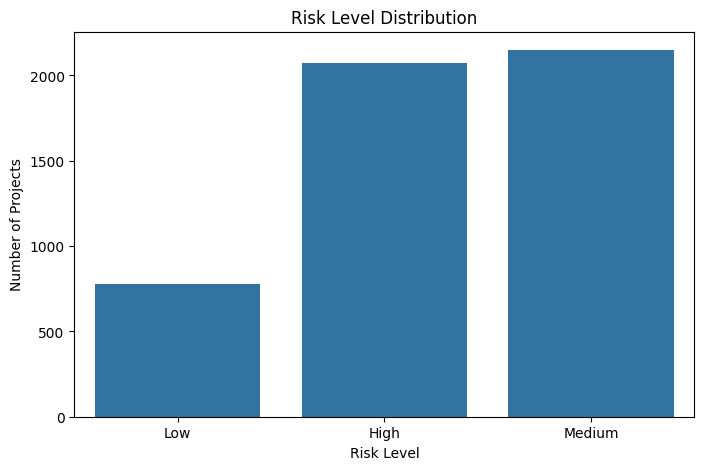

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="risk_level"
)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Projects")

plt.show()


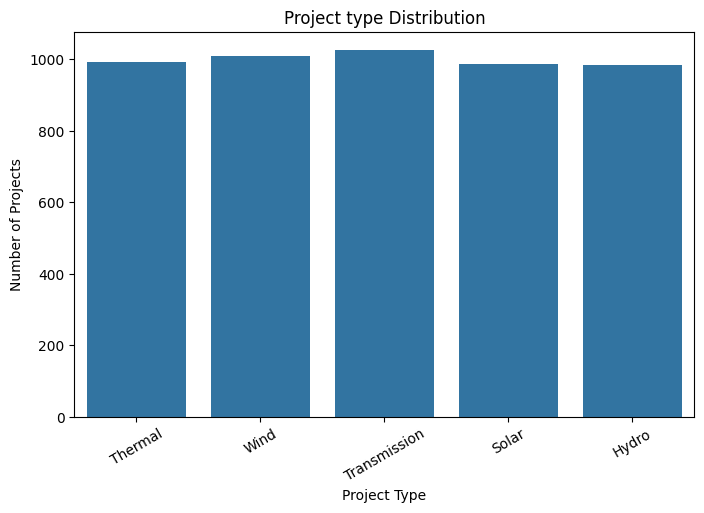

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="project_type"
)

plt.title("Project type Distribution")
plt.xlabel("Project Type")
plt.ylabel("Number of Projects")
plt.xticks(rotation=30)
plt.show()


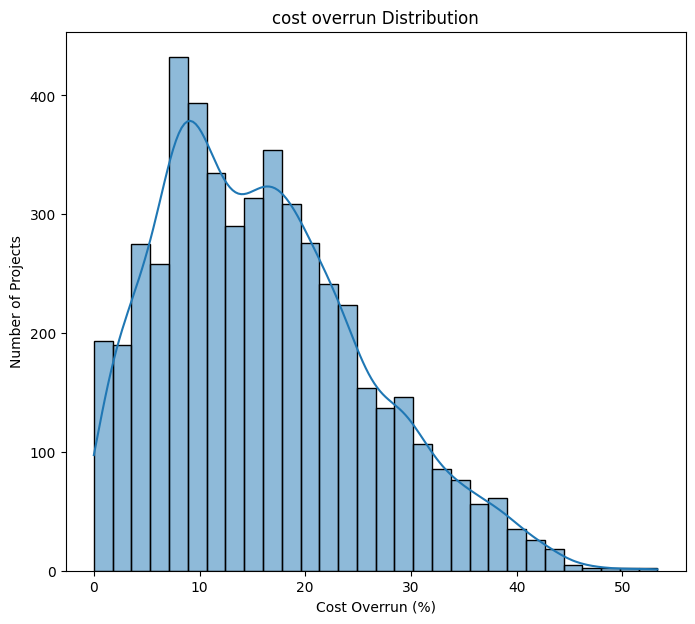

In [14]:
plt.figure(figsize=(8,7))

sns.histplot(
    df["cost_overrun_pct"],
    bins = 30,
   kde= True
)
plt.title("cost overrun Distribution")
plt.xlabel("Cost Overrun (%)")
plt.ylabel("Number of Projects")

plt.show()



Text(0, 0.5, 'Number of Projects')

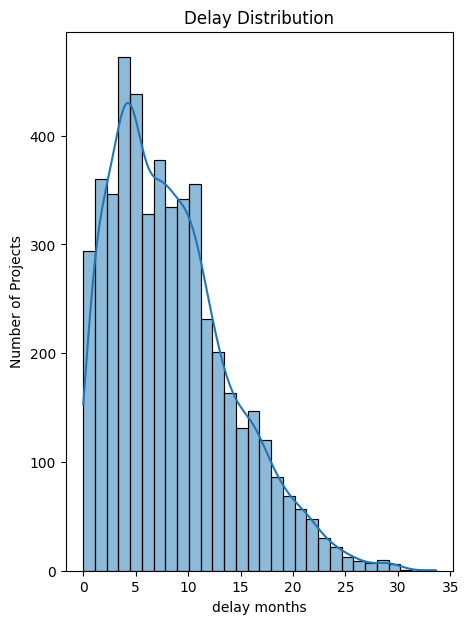

In [15]:
plt.figure(figsize =(5,7))

sns.histplot(
    df["delay_months"],
    bins = 30,
   kde= True
)
plt.title("Delay Distribution")
plt.xlabel("delay months")
plt.ylabel("Number of Projects")


In [16]:
cost_overrun_pct = 30

if cost_overrun_pct > 25:
    risk_level = "High"

print(risk_level)


High


In [17]:
def assign_risk(cost):
    if cost > 25:
        return "High"
    elif cost >= 10:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df["cost_overrun_pct"].apply(assign_risk)


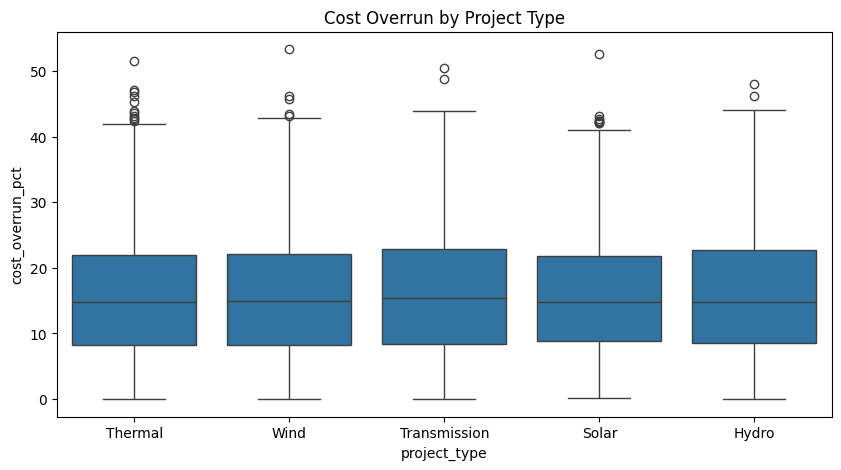

In [18]:
# Cost Overrun by Project Type
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="project_type",
    y="cost_overrun_pct"
)

plt.title("Cost Overrun by Project Type")

plt.show()


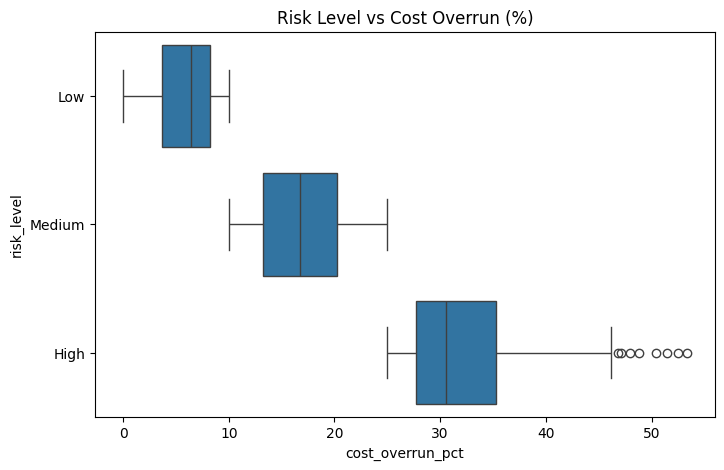

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="cost_overrun_pct",
    y="risk_level",
    order=["Low", "Medium", "High"]
)

plt.title("Risk Level vs Cost Overrun (%)")

plt.show()


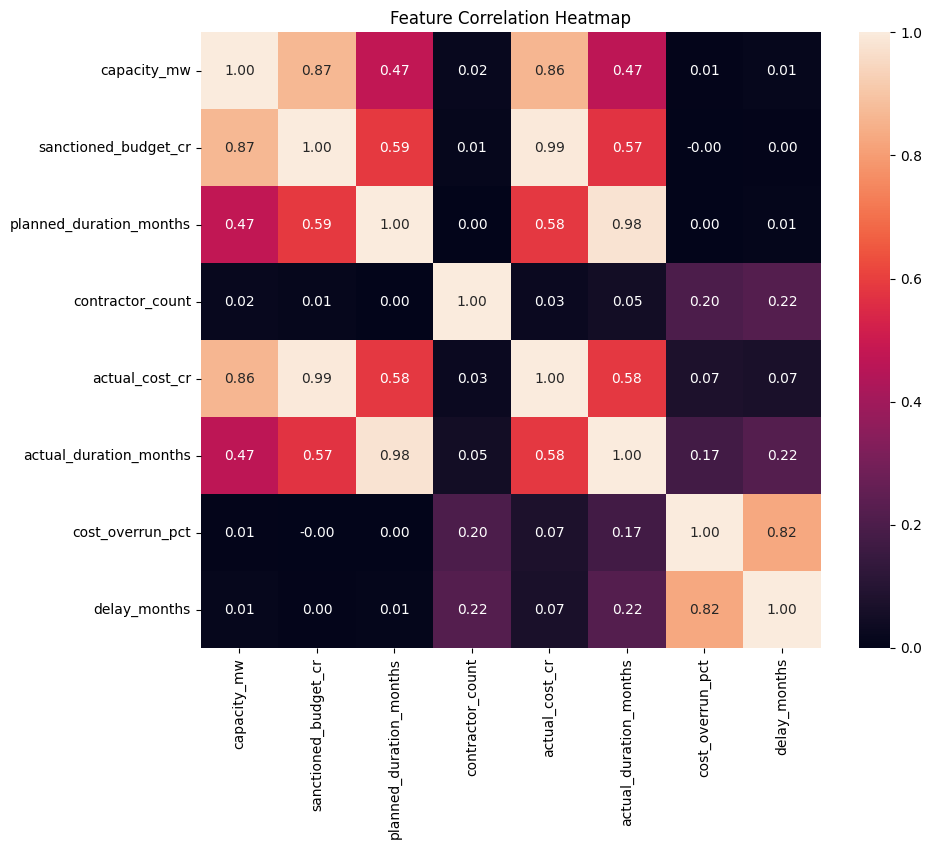

In [20]:
numeric_cols = df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")

plt.show()


In [21]:
df.columns


Index(['project_id', 'project_type', 'state', 'region', 'capacity_mw',
       'sanctioned_budget_cr', 'planned_duration_months', 'contractor_count',
       'land_acquisition_status', 'project_complexity', 'actual_cost_cr',
       'actual_duration_months', 'cost_overrun_pct', 'delay_months',
       'risk_level'],
      dtype='object')

In [34]:
X = df.drop(
    columns=[
        "actual_cost_cr",
        "actual_duration_months",
        "risk_level"
    ]
)


In [35]:
y_cost = df["actual_cost_cr"]

y_duration = df["actual_duration_months"]

y_risk = df["risk_level"]


In [36]:
categorical_cols = [
    "project_type",
    "state",
    "region",
    "land_acquisition_status",
    "project_complexity"
]


In [37]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded = encoder.fit_transform(
    X[categorical_cols]
)


In [38]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols)
)


In [39]:
X_numeric = X.drop(columns=categorical_cols)


In [40]:
X_final = pd.concat(
    [
        X_numeric.reset_index(drop=True),
        encoded_df.reset_index(drop=True)
    ],
    axis=1
)



In [41]:
print(X_final.shape)


(5000, 32)


In [51]:
import joblib

joblib.dump(
    cost_model,
    "cost_model.pkl"
)

print("Cost Model Saved")


Cost Model Saved


In [52]:
import os

print(os.path.exists("cost_model.pkl"))


True


In [53]:
y_cost = df["actual_cost_cr"]


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_cost,
    test_size=0.2,
    random_state=42
)


In [55]:
X = df.drop(
    columns=[
        "project_id",
        "actual_cost_cr"
    ]
)


In [56]:
X = df.drop(
    columns=[
        "project_id",
        "actual_duration_months"
    ]
)


In [57]:
df.select_dtypes(include="object").columns


Index(['project_id', 'project_type', 'state', 'region',
       'land_acquisition_status', 'project_complexity', 'risk_level'],
      dtype='object')

In [ ]:
print(X_train.dtypes)


project_id                           object
capacity_mw                           int64
sanctioned_budget_cr                float64
planned_duration_months               int64
contractor_count                      int64
cost_overrun_pct                    float64
delay_months                        float64
project_type_Hydro                  float64
project_type_Solar                  float64
project_type_Thermal                float64
project_type_Transmission           float64
project_type_Wind                   float64
state_Andhra Pradesh                float64
state_Gujarat                       float64
state_Haryana                       float64
state_Karnataka                     float64
state_Madhya Pradesh                float64
state_Maharashtra                   float64
state_Punjab                        float64
state_Rajasthan                     float64
state_Tamil Nadu                    float64
state_Uttar Pradesh                 float64
region_Central                  

In [ ]:
for col in X_train.select_dtypes(include='object').columns:
    print(col)
    print(X_train[col].head())
    print()


project_id
4227    P04228
4676    P04677
800     P00801
3671    P03672
4193    P04194
Name: project_id, dtype: object



In [62]:
print(X_train.columns.tolist())


['project_id', 'capacity_mw', 'sanctioned_budget_cr', 'planned_duration_months', 'contractor_count', 'cost_overrun_pct', 'delay_months', 'project_type_Hydro', 'project_type_Solar', 'project_type_Thermal', 'project_type_Transmission', 'project_type_Wind', 'state_Andhra Pradesh', 'state_Gujarat', 'state_Haryana', 'state_Karnataka', 'state_Madhya Pradesh', 'state_Maharashtra', 'state_Punjab', 'state_Rajasthan', 'state_Tamil Nadu', 'state_Uttar Pradesh', 'region_Central', 'region_North', 'region_South', 'region_West', 'land_acquisition_status_Complete', 'land_acquisition_status_Partial', 'land_acquisition_status_Pending', 'project_complexity_High', 'project_complexity_Low', 'project_complexity_Medium']


In [64]:
print(X_train['project_id'].head())


4227    P04228
4676    P04677
800     P00801
3671    P03672
4193    P04194
Name: project_id, dtype: object


In [ ]:
X_train = X_train.drop(columns=['project_id'])
X_test = X_test.drop(columns=['project_id'])


In [67]:
from sklearn.ensemble import RandomForestRegressor

cost_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

cost_model.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [68]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

predictions = cost_model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 67.77405530000007
RMSE: 161.99706591274136
R2  : 0.9995127045581904


In [ ]:
import joblib

joblib.dump(
    cost_model,
    "cost_model.pkl"
)

print("Cost Model Saved")


Cost Model Saved


In [69]:
X_train.head(10)


,capacity_mw,sanctioned_budget_cr,planned_duration_months,contractor_count,cost_overrun_pct,delay_months,project_type_Hydro,project_type_Solar,project_type_Thermal,project_type_Transmission,...,region_Central,region_North,region_South,region_West,land_acquisition_status_Complete,land_acquisition_status_Partial,land_acquisition_status_Pending,project_complexity_High,project_complexity_Low,project_complexity_Medium
4227,3883,21966.31,80,6,21.35,10.2,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4676,210,438.83,14,1,16.15,6.6,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
800,256,627.77,27,1,8.10,4.4,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3671,2351,4014.71,45,4,6.21,5.4,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4193,1133,3403.74,41,9,22.83,11.9,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2968,212,359.60,35,4,38.46,17.4,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4793,1861,8573.57,83,10,24.55,19.3,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4368,2582,14943.39,75,4,7.64,4.1,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2776,138,309.16,27,3,15.80,9.1,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2970,1481,4621.71,26,1,17.68,10.6,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 4227 to 860
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   project_id                        4000 non-null   object 
 1   capacity_mw                       4000 non-null   int64  
 2   sanctioned_budget_cr              4000 non-null   float64
 3   planned_duration_months           4000 non-null   int64  
 4   contractor_count                  4000 non-null   int64  
 5   cost_overrun_pct                  4000 non-null   float64
 6   delay_months                      4000 non-null   float64
 7   project_type_Hydro                4000 non-null   float64
 8   project_type_Solar                4000 non-null   float64
 9   project_type_Thermal              4000 non-null   float64
 10  project_type_Transmission         4000 non-null   float64
 11  project_type_Wind                 4000 non-null   float64
 12  state_And

In [ ]:
print(X_final.columns)


Index(['capacity_mw', 'sanctioned_budget_cr', 'planned_duration_months',
       'contractor_count', 'cost_overrun_pct', 'delay_months',
       'project_type_Hydro', 'project_type_Solar', 'project_type_Thermal',
       'project_type_Transmission', 'project_type_Wind',
       'state_Andhra Pradesh', 'state_Gujarat', 'state_Haryana',
       'state_Karnataka', 'state_Madhya Pradesh', 'state_Maharashtra',
       'state_Punjab', 'state_Rajasthan', 'state_Tamil Nadu',
       'state_Uttar Pradesh', 'region_Central', 'region_North', 'region_South',
       'region_West', 'land_acquisition_status_Complete',
       'land_acquisition_status_Partial', 'land_acquisition_status_Pending',
       'project_complexity_High', 'project_complexity_Low',
       'project_complexity_Medium'],
      dtype='object')


In [ ]:
X_final = X_final.drop(columns=["project_id"])


In [ ]:
X_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   capacity_mw                       5000 non-null   int64  
 1   sanctioned_budget_cr              5000 non-null   float64
 2   planned_duration_months           5000 non-null   int64  
 3   contractor_count                  5000 non-null   int64  
 4   cost_overrun_pct                  5000 non-null   float64
 5   delay_months                      5000 non-null   float64
 6   project_type_Hydro                5000 non-null   float64
 7   project_type_Solar                5000 non-null   float64
 8   project_type_Thermal              5000 non-null   float64
 9   project_type_Transmission         5000 non-null   float64
 10  project_type_Wind                 5000 non-null   float64
 11  state_Andhra Pradesh              5000 non-null   float64
 12  state_

In [ ]:
# Duration Prediction model


In [75]:
y_duration = df["actual_duration_months"]


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_duration,
    test_size=0.2,
    random_state=42
)


In [79]:
X_train = X_train.drop(columns=['project_id'])
X_test = X_test.drop(columns=['project_id'])


In [80]:
from sklearn.ensemble import RandomForestRegressor

duration_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

duration_model.fit(
    X_train,
    y_train
)


RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
pred = duration_model.predict(X_test)

print(
    "R2:",
    r2_score(y_test, pred)
    
)


R2: 0.9995673159196196


In [ ]:
joblib.dump(
    duration_model,
    "duration_model.pkl"
)

print("Duration Model Saved")


Duration Model Saved


In [ ]:
#Risk Classification Model


In [85]:
y_risk = df["risk_level"]


In [91]:
X_train = X_train.drop(columns=['project_id'])
X_test = X_test.drop(columns=['project_id'])


In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_risk,
    test_size=0.2,
    random_state=42
)


In [92]:
from sklearn.ensemble import RandomForestClassifier

risk_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

risk_model.fit(
    X_train,
    y_train
)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred = risk_model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

print(
    classification_report(
        y_test,
        pred
    )
)


Accuracy: 0.997
              precision    recall  f1-score   support

        High       1.00      0.99      1.00       412
         Low       1.00      1.00      1.00       137
      Medium       0.99      1.00      1.00       451

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
joblib.dump(
    risk_model,
    "risk_model.pkl"
)

print("Risk Model Saved")


Risk Model Saved


In [ ]:
import os

files = [
    "cost_model.pkl",
    "duration_model.pkl",
    "risk_model.pkl",
    "encoder.pkl"
]

for f in files:
    print(
        f,
        os.path.exists(f)
    )


cost_model.pkl True
duration_model.pkl True
risk_model.pkl True
encoder.pkl False


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    predictions
)

print(mae)


67.77405530000007


In [ ]:
y_cost = df["actual_cost_cr"]

y_duration = df["actual_duration_months"]

y_risk = df["risk_level"]


In [ ]:
print(type(encoder))


<class 'sklearn.preprocessing._encoders.OneHotEncoder'>


In [ ]:
import joblib

joblib.dump(
    encoder,
    "encoder.pkl"
)

print("Encoder Saved")


Encoder Saved


In [ ]:
import os

print(os.path.exists("encoder.pkl"))


True


In [70]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

cost_pred = cost_model.predict(X_test)

mae = mean_absolute_error(y_test, cost_pred)

rmse = mean_squared_error(
    y_test,
    cost_pred
) ** 0.5

r2 = r2_score(
    y_test,
    cost_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 67.77405530000007
RMSE: 161.99706591274136
R2: 0.9995127045581904


In [81]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

duration_pred = duration_model.predict(X_test)

mae = mean_absolute_error(y_test, cost_pred)

rmse = mean_squared_error(
    y_test,
    cost_pred
) ** 0.5

r2 = r2_score(
    y_test,
    cost_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 6458.8866612
RMSE: 9760.335075138444
R2: -132432.48613905694


In [ ]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import os

BASE = "/Users/khushimishra/Documents/Hackathon"
df = pd.read_csv(f"{BASE}/powercast_dataset.csv")

print("Dataset loaded:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(2))

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print("\nCleaned columns:", df.columns.tolist())
categorical_cols = [
    "project_type",
    "state",
    "region",
    "land_acquisition_status",
    "project_complexity"
]

numeric_cols = [
    "capacity_mw",
    "sanctioned_budget_cr",
    "planned_duration_months",
    "contractor_count",
    "cost_overrun_pct",
    "delay_months"
]

target_cost     = "actual_cost_cr"
target_duration = "actual_duration_months"
target_risk     = "risk_level"

all_needed = categorical_cols + numeric_cols + [target_cost, target_duration, target_risk]
missing = [c for c in all_needed if c not in df.columns]

if missing:
    print("\n⚠ Missing columns:", missing)
    print("Available columns:", df.columns.tolist())
    print("\nAuto-generating targets from available data...")

    # If targets don't exist, generate them from input features
    if target_cost not in df.columns:
        if "sanctioned_budget_cr" in df.columns and "cost_overrun_pct" in df.columns:
            df[target_cost] = df["sanctioned_budget_cr"] * (1 + df["cost_overrun_pct"] / 100)
        else:
            df[target_cost] = df[numeric_cols[1]] * np.random.uniform(1.0, 1.4, len(df))

    if target_duration not in df.columns:
        if "planned_duration_months" in df.columns and "delay_months" in df.columns:
            df[target_duration] = df["planned_duration_months"] + df["delay_months"]
        else:
            df[target_duration] = df[numeric_cols[2]] * np.random.uniform(1.0, 1.3, len(df))

    if target_risk not in df.columns:
        conditions = [
            df[target_cost] > df["sanctioned_budget_cr"] * 1.25,
            df[target_cost] > df["sanctioned_budget_cr"] * 1.10,
        ]
        choices = ["High", "Medium"]
        df[target_risk] = np.select(conditions, choices, default="Low")

print("\nTarget distributions:")
print(df[target_risk].value_counts())

df = df.dropna(subset=categorical_cols + numeric_cols + [target_cost, target_duration, target_risk])
print(f"\nRows after dropping nulls: {len(df)}")

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(df[categorical_cols])

encoded = encoder.transform(df[categorical_cols])
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols)
)

numeric_df = df[numeric_cols].reset_index(drop=True)
final_df = pd.concat([numeric_df, encoded_df.reset_index(drop=True)], axis=1)

print(f"\nFinal feature matrix shape: {final_df.shape}")

X = final_df
y_cost     = df[target_cost].values
y_duration = df[target_duration].values
y_risk     = df[target_risk].values

X_train, X_test, yc_train, yc_test, yd_train, yd_test, yr_train, yr_test = train_test_split(
    X, y_cost, y_duration, y_risk, test_size=0.2, random_state=42
)

print("\nTraining cost model...")
cost_model = RandomForestRegressor(n_estimators=100, random_state=42)
cost_model.fit(X_train, yc_train)

print("Training duration model...")
duration_model = RandomForestRegressor(n_estimators=100, random_state=42)
duration_model.fit(X_train, yd_train)

print("Training risk model...")
risk_model = RandomForestClassifier(n_estimators=100, random_state=42)
risk_model.fit(X_train, yr_train)

from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

cost_pred = cost_model.predict(X_test)
dur_pred  = duration_model.predict(X_test)
risk_pred = risk_model.predict(X_test)

print(" Model Performance")
print(f"Cost Model     | MAE: {mean_absolute_error(yc_test, cost_pred):.2f} | R²: {r2_score(yc_test, cost_pred):.3f}")
print(f"Duration Model | MAE: {mean_absolute_error(yd_test, dur_pred):.2f} | R²: {r2_score(yd_test, dur_pred):.3f}")
print(f"Risk Model     | Accuracy: {accuracy_score(yr_test, risk_pred):.3f}")

joblib.dump(cost_model,     f"{BASE}/cost_model.pkl")
joblib.dump(duration_model, f"{BASE}/duration_model.pkl")
joblib.dump(risk_model,     f"{BASE}/risk_model.pkl")
joblib.dump(encoder,        f"{BASE}/encoder.pkl")

print(" All models saved successfully!")
print(f"   {BASE}/cost_model.pkl")
print(f"   {BASE}/duration_model.pkl")
print(f"   {BASE}/risk_model.pkl")
print(f"   {BASE}/encoder.pkl")


Dataset loaded: (5000, 15)
Columns: ['project_id', 'project_type', 'state', 'region', 'capacity_mw', 'sanctioned_budget_cr', 'planned_duration_months', 'contractor_count', 'land_acquisition_status', 'project_complexity', 'actual_cost_cr', 'actual_duration_months', 'cost_overrun_pct', 'delay_months', 'risk_level']
  project_id project_type          state region  capacity_mw  \
0     P00001      Thermal         Punjab  North         4272   
1     P00002      Thermal  Uttar Pradesh  North         2933   

   sanctioned_budget_cr  planned_duration_months  contractor_count  \
0              20878.98                       93                 3   
1               9465.67                       56                 1   

  land_acquisition_status project_complexity  actual_cost_cr  \
0                Complete             Medium        22533.22   
1                Complete             Medium        10243.65   

   actual_duration_months  cost_overrun_pct  delay_months risk_level  
0                